# RFM Value Calculation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("online retail cleaned.csv", parse_dates=['InvoiceDate'])

# Reference date — dataset ki last date + 1 din
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('Total Price',  'sum')
).reset_index()

print(rfm.head(10))
print(rfm.describe())

   Customer ID  Recency  Frequency  Monetary
0        12346      165         11    372.86
1        12347        3          2   1323.32
2        12348       74          1    222.16
3        12349       43          3   2630.34
4        12351       11          1    300.93
5        12352       11          2    343.80
6        12353       44          1    317.76
7        12355      203          1    457.01
8        12356       16          3   2094.12
9        12357       24          2  10130.47
        Customer ID      Recency    Frequency       Monetary
count   4226.000000  4226.000000  4226.000000    4226.000000
mean   15347.233791    92.010885     4.290819    1411.727292
std     1701.033862    97.468754     7.589086    3379.100221
min    12346.000000     1.000000     1.000000       0.950000
25%    13880.250000    18.250000     1.000000     275.542500
50%    15348.500000    53.000000     2.000000     620.575000
75%    16833.750000   138.000000     5.000000    1491.167500
max    18287.0000

# RFM Score given

In [3]:
# Recency — kam din = better = score 5
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])

# Frequency — zyada orders = better = score 5
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5])

# Monetary — zyada spend = better = score 5
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5])

# Combined RFM Score
rfm['RFM_Score'] = (rfm['R_Score'].astype(int)
                  + rfm['F_Score'].astype(int)
                  + rfm['M_Score'].astype(int))

print(rfm[['Customer ID','Recency','Frequency','Monetary',
           'R_Score','F_Score','M_Score','RFM_Score']].head(10))

   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score  \
0        12346      165         11    372.86       2       5       2   
1        12347        3          2   1323.32       5       2       4   
2        12348       74          1    222.16       2       1       1   
3        12349       43          3   2630.34       3       3       5   
4        12351       11          1    300.93       5       1       2   
5        12352       11          2    343.80       5       2       2   
6        12353       44          1    317.76       3       1       2   
7        12355      203          1    457.01       1       1       3   
8        12356       16          3   2094.12       4       3       5   
9        12357       24          2  10130.47       4       2       5   

   RFM_Score  
0          9  
1         11  
2          4  
3         11  
4          8  
5          9  
6          6  
7          5  
8         12  
9         11  


# customer Segmentation

In [4]:
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'           # Best customers
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'     # Regular aane wale
    elif r >= 4 and f <= 2:
        return 'New Customers'       # Haal mein aaye, zyada order nahi
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists' # Thoda push chahiye
    elif r <= 2 and f >= 3:
        return 'At Risk'             # Pehle ache the, ab nahi aa rahe
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'      # High spender but gone
    elif r == 1 and f == 1:
        return 'Lost'                # Bilkul nahi aate
    else:
        return 'Hibernating'         # Beech wale

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print(rfm['Segment'].value_counts())

Segment
Loyal Customers        962
Champions              901
At Risk                672
Hibernating            527
New Customers          359
Potential Loyalists    334
Lost                   298
Cant Lose Them         173
Name: count, dtype: int64


# Kmean Clustering

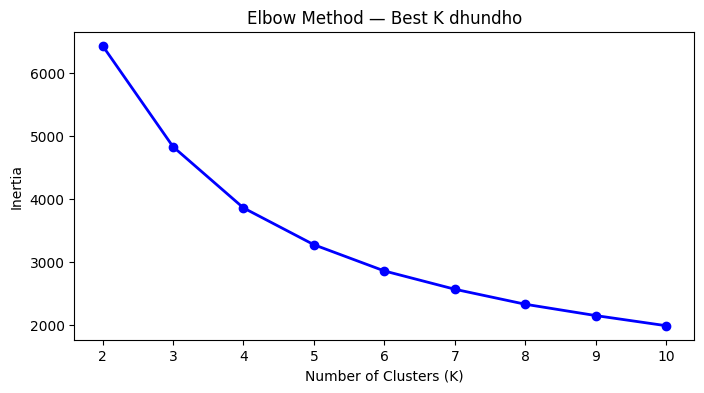

In [5]:
# Log transform karo — skewed data ke liye
rfm_log = rfm[['Recency','Frequency','Monetary']].copy()
rfm_log['Recency']   = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

# Scale karo
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Elbow method — best K dhundho
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-', linewidth=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Best K dhundho")
plt.savefig("plots/elbow_curve.png")
plt.show()
# Jahan curve mein 'elbow' dikhe wahi K choose karo — usually 4 ya 5

In [6]:
# K=4 se final clustering
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(rfm_scaled)

# Cluster profiles dekho
cluster_summary = rfm.groupby('Cluster').agg(
    Customers = ('Customer ID', 'count'),
    Recency   = ('Recency',     'mean'),
    Frequency = ('Frequency',   'mean'),
    Monetary  = ('Monetary',    'mean')
).round(1)

print(cluster_summary)

         Customers  Recency  Frequency  Monetary
Cluster                                         
0             1207     79.6        4.2    1489.0
1             1349    192.6        1.3     270.0
2              726     12.8       13.1    4617.9
3              944     25.1        1.9     478.8


# Visualization

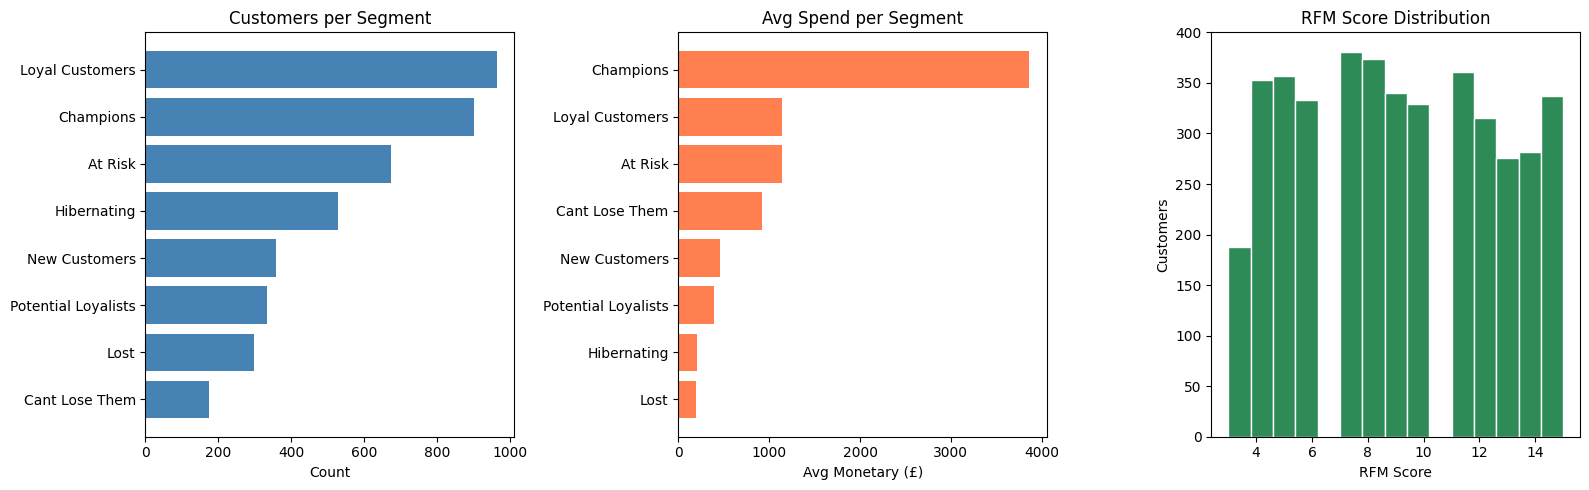

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Segment wise customer count
seg_counts = rfm['Segment'].value_counts()
axes[0].barh(seg_counts.index, seg_counts.values, color='steelblue')
axes[0].set_title("Customers per Segment")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# Segment wise average monetary
seg_money = rfm.groupby('Segment')['Monetary'].mean().sort_values()
axes[1].barh(seg_money.index, seg_money.values, color='coral')
axes[1].set_title("Avg Spend per Segment")
axes[1].set_xlabel("Avg Monetary (£)")

# RFM Score distribution
axes[2].hist(rfm['RFM_Score'], bins=15,
             color='seagreen', edgecolor='white')
axes[2].set_title("RFM Score Distribution")
axes[2].set_xlabel("RFM Score")
axes[2].set_ylabel("Customers")

plt.tight_layout()
plt.savefig("plots/rfm_analysis.png")
plt.show()

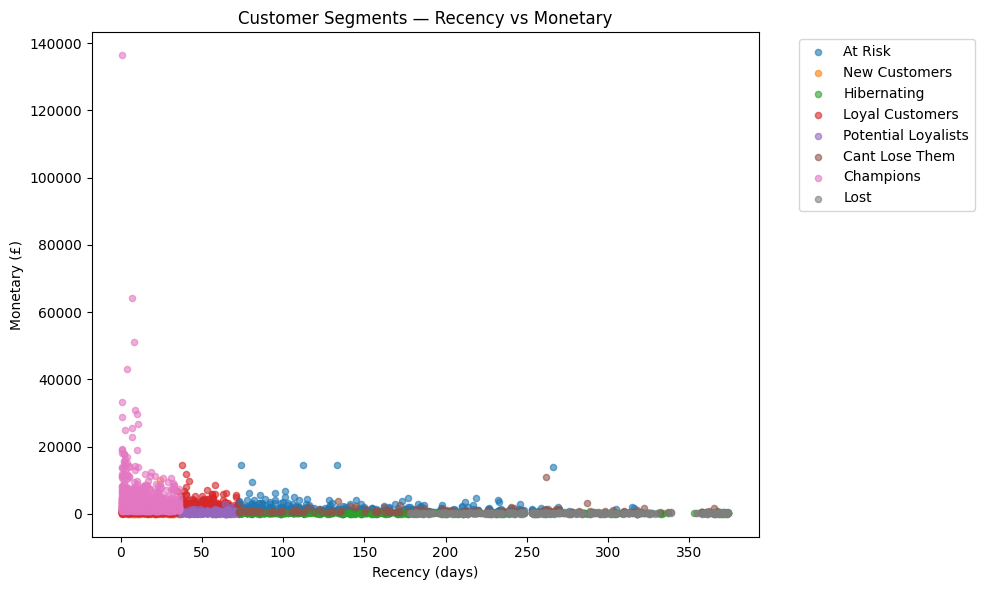

In [8]:
# Scatter plot — Recency vs Monetary, color = Segment
plt.figure(figsize=(10, 6))
segments = rfm['Segment'].unique()
colors = plt.cm.tab10.colors

for i, seg in enumerate(segments):
    subset = rfm[rfm['Segment'] == seg]
    plt.scatter(subset['Recency'], subset['Monetary'],
                label=seg, alpha=0.6, s=20, color=colors[i])

plt.xlabel("Recency (days)")
plt.ylabel("Monetary (£)")
plt.title("Customer Segments — Recency vs Monetary")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("plots/rfm_scatter.png")
plt.show()

In [9]:
rfm.to_csv("rfm_segments.csv", index=False)

# Quick summary print karo
print("\n===== RFM SUMMARY =====")
for seg in rfm['Segment'].value_counts().index:
    subset = rfm[rfm['Segment'] == seg]
    print(f"\n{seg} ({len(subset)} customers)")
    print(f"  Avg Recency  : {subset['Recency'].mean():.0f} days")
    print(f"  Avg Frequency: {subset['Frequency'].mean():.1f} orders")
    print(f"  Avg Monetary : £{subset['Monetary'].mean():.0f}")


===== RFM SUMMARY =====

Loyal Customers (962 customers)
  Avg Recency  : 36 days
  Avg Frequency: 3.9 orders
  Avg Monetary : £1143

Champions (901 customers)
  Avg Recency  : 14 days
  Avg Frequency: 11.1 orders
  Avg Monetary : £3866

At Risk (672 customers)
  Avg Recency  : 151 days
  Avg Frequency: 3.6 orders
  Avg Monetary : £1136

Hibernating (527 customers)
  Avg Recency  : 190 days
  Avg Frequency: 1.1 orders
  Avg Monetary : £208

New Customers (359 customers)
  Avg Recency  : 20 days
  Avg Frequency: 1.3 orders
  Avg Monetary : £452

Potential Loyalists (334 customers)
  Avg Recency  : 54 days
  Avg Frequency: 1.2 orders
  Avg Monetary : £390

Lost (298 customers)
  Avg Recency  : 277 days
  Avg Frequency: 1.0 orders
  Avg Monetary : £197

Cant Lose Them (173 customers)
  Avg Recency  : 187 days
  Avg Frequency: 1.4 orders
  Avg Monetary : £915
